In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

In [22]:
x=6*np.random.rand(200,1)
y=0.8*x**2+0.9*x+2+np.random.randn(200,1)


In [23]:
print(x)

[[5.48880689]
 [4.69012538]
 [4.76276541]
 [2.20119722]
 [0.40396676]
 [4.00585294]
 [3.88379148]
 [3.85187226]
 [1.30977779]
 [4.32813075]
 [5.43289687]
 [2.34373551]
 [0.01709426]
 [4.24241305]
 [3.27936552]
 [2.90555212]
 [5.73101542]
 [5.83711761]
 [4.90381924]
 [0.53914337]
 [0.68009757]
 [0.93706217]
 [0.86874381]
 [0.48696582]
 [4.07330183]
 [0.95411338]
 [1.00810525]
 [4.62391333]
 [0.87017215]
 [3.2822385 ]
 [5.69833562]
 [0.1483955 ]
 [5.7100227 ]
 [3.43119656]
 [3.44736807]
 [4.49347742]
 [3.88927012]
 [0.40379861]
 [0.39430095]
 [4.42405612]
 [5.54829727]
 [5.14598734]
 [2.47148323]
 [1.96617825]
 [0.50386285]
 [4.06798529]
 [3.32325413]
 [2.4379454 ]
 [2.17500106]
 [0.99660496]
 [3.59710053]
 [1.21896287]
 [3.24558575]
 [3.45525788]
 [0.5231879 ]
 [4.40640703]
 [1.02620929]
 [0.5798012 ]
 [5.35770443]
 [1.44131819]
 [5.20390113]
 [4.9210723 ]
 [1.24940889]
 [4.50721086]
 [3.44024607]
 [0.22833734]
 [3.82604159]
 [3.02006082]
 [2.93174229]
 [4.92329419]
 [4.4017411 ]
 [0.69

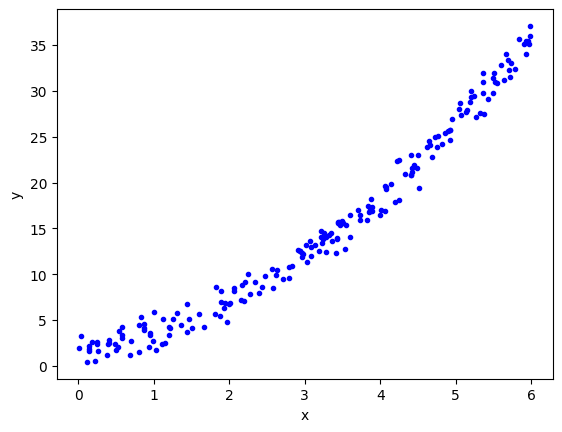

In [24]:
plt.plot(x,y,'b.')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [25]:
#Train Test Splits
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=3)


In [26]:
#Applying the linear Regression MOdel
lr=LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [27]:
y_pred=lr.predict(x_test)
r2_score_lr=r2_score(y_test,y_pred)
print("R2 Score is :",r2_score_lr)

R2 Score is : 0.9442428403013792


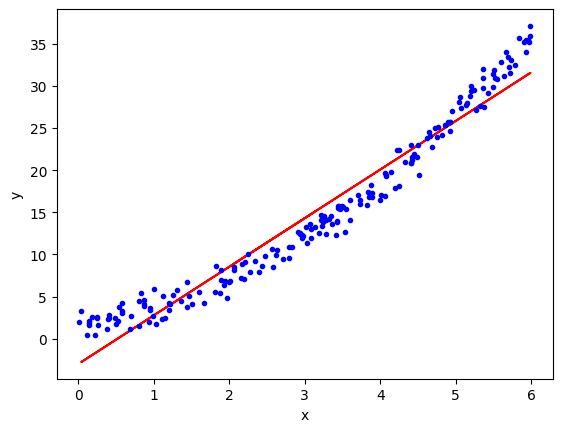

In [28]:
plt.plot(x_train,lr.predict(x_train),color='r')
plt.plot(x,y,'b.')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

#**Applying Polynomial Linear Regression**

In [29]:
poly=PolynomialFeatures(degree=2,include_bias=True)
x_train_trans=poly.fit_transform(x_train)
x_test_trans=poly.transform(x_test)


In [30]:
print(x_train[0])

[2.05822537]


In [31]:
print(x_train_trans[0])

[1.         2.05822537 4.23629168]


In [32]:
lr2=LinearRegression()
lr2.fit(x_train_trans,y_train)

LinearRegression()

In [33]:
y_pred=lr2.predict(x_test_trans)

In [34]:
r2_score(y_test,y_pred)

0.9927413952513512

In [35]:
print(lr2.coef_)

[[0.        1.1016086 0.7629927]]


In [36]:
print(lr2.intercept_)

[1.80977716]


In [39]:
x_new=np.linspace(-3,3,200).reshape(200,1)
x_new_poly=poly.transform(x_new)
y_new=lr2.predict(x_new_poly)

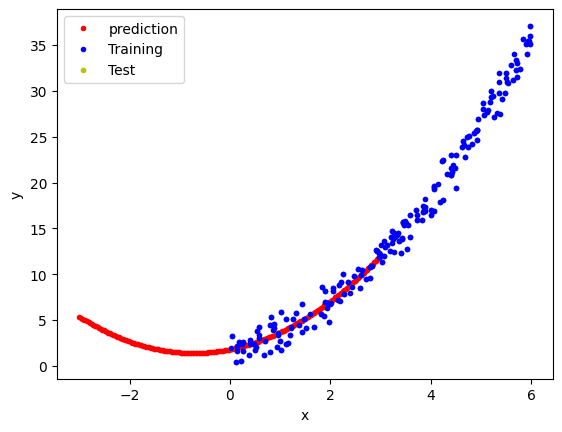

In [42]:
plt.plot(x_new,y_new,'r.',linewidth=2,label='prediction')
plt.plot(x_train,y_train,'b.',label='Training')
plt.plot(x_test,y_test,'y.',label='Test')
plt.plot(x,y,'b.')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

#**Visualize the Data Using 3D plots**

In [43]:
x=7*np.random.rand(100,1)-2.8
y=7*np.random.rand(100,1)-2.8
z=x**2 + y**2 + 0.2*y + 0.1*x*y +2 + np.random.rand(100,1)

In [46]:
import plotly.express as px
df=px.data.iris()
fig=px.scatter_3d(df,x=x.ravel(),y=y.ravel(),z=z.ravel())
fig.show()